In [1]:
%pdb off

Automatic pdb calling has been turned OFF


In [1]:
%load_ext autoreload
%autoreload 2

import pipeline
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import count
import time
import pickle
import shutil
import sys
import itertools
from collections import defaultdict
import geopandas as gpd
from tqdm.auto import tqdm
from libpysal.weights import Queen
import esda
import glob, os, re
from scipy.stats import ks_2samp
import math
from haversine import haversine
from scipy.stats import wasserstein_distance

import plotly.io as pio
pio.renderers.default = "notebook"

seed = 21
vers = 'agg'
agg = False

if vers == "6":
    fpath = Path('data/undir_trials/6h/thresholded_networks/0_network.txt')
    save_dir = Path(f'data/undir_trials/6h/tests/seed{seed}')
    data = Path('data/undir_trials/depnet_undirected.gz')
elif vers == '24':
    fpath = Path('data/undir_trials/24h/0_network_24h.txt')
    save_dir = Path(f'data/undir_trials/24h/tests/seed{seed}')
    data = Path('data/undir_trials/24h/depnet_undirected_24h.gz')
elif vers == 'agg':
    fpath = Path('data/agg/agg_network_24h.pkl')
    save_dir = Path(f'data/agg/undir_dep/tests/seed{seed}')
    agg = True
else:
    print("Invalid version.")

save_dir.mkdir(parents=True, exist_ok=True)

print(f"Version: {vers} | Seed: {seed}")

Version: agg | Seed: 21


In [ ]:
# blank canvas for checking file structure if needed


14536


### Thresholding and Building Network(s)

In [ ]:
# --- dependency distribution ---

# reading in + dealing with missing values
df = pd.read_csv(data)
df['DEP'] = pd.to_numeric(df['DEP'], errors='coerce')
df = df.dropna(subset=['DEP'])

# sampling for performance
plot_data = df['DEP'].sample(100000)
print(plot_data.describe())

sns.displot(plot_data, bins=30, kde=True, stat='probability', log_scale=True)
plt.margins(x=0)

# --- num removed vs binned values ---

dep_nonzero = df.loc[df['DEP'] > 0, 'DEP'].sort_values().values
total_edges = len(df)
zero_edges = total_edges - len(dep_nonzero)

print(f"Total edges: {total_edges}")
print(f"Zero-DEP edges: {zero_edges}")
print(f"Nonzero DEP range: [{dep_nonzero.min():.2e}, {dep_nonzero.max():.2e}]")

# log-spaced bins across the nonzero DEP range
bins = np.logspace(np.log10(dep_nonzero.min()), np.log10(dep_nonzero.max()), 200)

# for each threshold, edges retained = nonzero edges with DEP >= threshold
edges_retained = len(dep_nonzero) - np.searchsorted(dep_nonzero, bins, side='left')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bins, edges_retained)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('DEP threshold')
ax.set_ylabel('Number of edges retained')
ax.set_title('Edges retained vs DEP threshold')

ax.axhline(y=1_000_000, color='r', linestyle='--', label='1M edges')
ax.axhline(y=10_000, color='orange', linestyle='--', label='10k edges')
ax.legend()
plt.show()

# find approximate thresholds
vals = []
for target, label in [(1_000_000, 'DEP_low (~1M)'), (10_000, 'DEP_high (~10k)')]:
    idx = np.argmin(np.abs(edges_retained - target))
    vals.append(bins[idx])
    print(f"{label}: DEP â‰ˆ {bins[idx]:.6e}, edges retained = {edges_retained[idx]}")

DEP_low = vals[0]
DEP_high = vals[1]

In [ ]:
all = 0

# reloading df if needed
if 'df' not in globals():
    df = pd.read_csv(data)
    df['DEP'] = pd.to_numeric(df['DEP'], errors='coerce')
    df = df.dropna(subset=['DEP'])

if all:
    # filtering
    DEP_range = df[df['DEP'].between(DEP_low, DEP_high)]
    # calculating thresholds with bounded range
    quantiles = np.quantile(DEP_range['DEP'], [0.25, 0.5, 0.75])
    thresholds = np.concatenate([[DEP_low], quantiles, [DEP_high]])

    # creating networks with original uncapped df
    for i, threshold in zip(count(0, 0.25), thresholds):
        # filter
        thresholded_df = df[df['DEP'] >= threshold]
        
        # save df directly
        filepath = f'data/undir_trials/thresholded_networks/{i}_network.txt'
        thresholded_df.to_csv(filepath, sep=' ', index=False, header=False)
        
        print(f"Saved {filepath} with {len(thresholded_df)} edges")
else:
    thresholded_df = df[df['DEP'] >= DEP_low]
    filepath = f'data/undir_trials/24h/network.txt'
    thresholded_df.to_csv(filepath, sep=' ', index=False, header=False)
    print(f"Saved {filepath} with {len(thresholded_df)} edges")

Saved data/undir_trials/24h/network.txt with 991526 edges


### Test Run Template

In [2]:
# set parameters
p, q, dim = 4, 0.25, 192
cat_threshold = 20
controlled = True
weight = 'dep'
if weight:
    weighted = True
else:
    weighted = False
strength = 0.5

print(f'weight={weight} | weighted={weighted} | strength={strength}')

weight=dep | weighted=True | strength=0.5


In [8]:
# --- new split if needed ---

print(f"Using seed: {seed}")
print(f"Version check: {vers}")

split_path = save_dir / f"split_{seed}_{weight}.pkl"
train_path = save_dir / f"train_{seed}_{weight}.txt"

if split_path.is_file():
    print(f"Split already exists for seed: {seed}. Exiting...")
    sys.exit()

G, train_neg, test_pos, test_neg = pipeline.prepare_data(
    fpath, frac=.25, seed=seed, weight=weight, agg=agg, meta=True,
    trainfile=train_path, controlled=controlled)

save_dir.mkdir(parents=True, exist_ok=True)
with open(split_path, 'wb') as f:
    pickle.dump((G, train_neg, test_pos, test_neg), f, pickle.HIGHEST_PROTOCOL)
print(f"Saved split â†’ {split_path}")

Using seed: 21
Version check: agg


Sampling non-edges (fast):   0%|          | 0/1285218 [00:00<?, ?edge/s]

Sampling non-edges (fast):   0%|          | 0/3892573 [00:00<?, ?edge/s]

Wrote training graph: 14794 nodes, 3916402 edges
Saved split â†’ data\agg\undir_dep\tests\seed21\split_21_dep.pkl


In [ ]:
# --- single test ---

print(f"Using seed: {seed}")
print(f"Version check: {vers} (agg={agg})")

file_path = save_dir / f"split_{seed}_{weight}.pkl"
with open(file_path, 'rb') as f:
            G, train_neg, test_pos, test_neg = pickle.load(f)

feats = ['emb']

auc, emb_map, strength_auc = pipeline.run_pipeline(save_dir / f"train_{seed}_{weight}.txt", 
                                train_neg, test_pos, test_neg, seed=seed,
                                p=p, q=q, dim=192, workers=6, weighted=weighted,
                                features=feats, cat_threshold=cat_threshold, G=G,
                                agg=agg, strength=strength)

feats_id = '_'.join(feats) if isinstance(feats, list) else feats
with open(save_dir / f'weight_{weight}/w{weight}-strength{strength}-feats_{feats_id}.txt', 'w') as f:
        f.write(str(auc) + '\n')
        f.write(str(strength_auc))
        print('Score saved.')

Using seed: 21
Version check: agg (agg=True)


  0%|          | 0/147940 [00:00<?, ?it/s]

Took 00:01:13.00 to generate walks


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Took 00:00:48.36 to train embeddings
Embeddings generated: 14794 nodes, dim=192
Training matrix: 7831097 samples x 192 features
[emb (hadamard)]  AUC = 0.6841
[emb (hadamard)]  strength AUC (DEP > q0.5=4.646e-08) = 0.8312  (train strong frac = 0.500)
Score saved.


In [5]:
# --- comprehensive test ---

print(f"Using seed: {seed}")
print(f"Version check: {vers} (agg={agg})")

file_path = save_dir / f"split_{seed}_{weight}.pkl"
with open(file_path, 'rb') as f:
            G, train_neg, test_pos, test_neg = pickle.load(f)
            
feats_list = [
        ['time'],
        ['comm'],
        ['income'],
        ['time', 'income'],
        ['dist'],
        ['dist', 'time'],
        ['dist', 'income'],
        ['dist', 'time', 'income'],
        ['dist', 'comm', 'time', 'income'],
        ['emb', 'dist'],
        ['emb', 'time'],
        ['emb', 'income'],
        ['emb', 'comm', 'time', 'income'],
        'all'
]

results = {}
for feats in feats_list:
        print(f'NOW TESTING: {feats}')
        auc, _, strength_auc = pipeline.run_pipeline(save_dir / f"train_{seed}_w{weight}.txt", 
                                        train_neg, test_pos, test_neg, seed=seed,
                                        p=p, q=q, dim=192, workers=6, weighted=weighted,
                                        features=feats, cat_threshold=cat_threshold, G=G,
                                        agg=agg, embedding_map=emb_map, strength=strength)

        feats_id = '_'.join(feats) if isinstance(feats, list) else feats
        results[feats_id] = (auc, strength_auc)

with open(save_dir / f'weight_{weight}/w{weight}-strength{strength}_comprehensive.txt', 'w') as f:
        for f_id, result in results.items():
                auc, strength_auc = result
                f.write(f'Result for features: {f_id} -> AUC: {auc:.6f} | Strength AUC: {strength_auc:.6f}\n')

print('All scores saved.')

Using seed: 21
Version check: agg (agg=True)
NOW TESTING: ['time']
Training matrix: 7831097 samples x 1 features
[time]  AUC = 0.5724
[time]  strength AUC (DEP > q0.5=4.646e-08) = 0.5020  (train strong frac = 0.500)
Score saved.
NOW TESTING: ['comm']
Running Infomap...
Done.
Assigned 4 communities
Training matrix: 7831097 samples x 1 features
[comm]  AUC = 0.5065
[comm]  strength AUC (DEP > q0.5=4.646e-08) = 0.6073  (train strong frac = 0.500)
Score saved.
NOW TESTING: ['income']
Training matrix: 7831097 samples x 1 features
[income]  AUC = 0.6308
[income]  strength AUC (DEP > q0.5=4.646e-08) = 0.5458  (train strong frac = 0.500)
Score saved.
NOW TESTING: ['time', 'income']
Training matrix: 7831097 samples x 2 features
[time+income]  AUC = 0.6397
[time+income]  strength AUC (DEP > q0.5=4.646e-08) = 0.5469  (train strong frac = 0.500)
Score saved.
NOW TESTING: ['dist']
Training matrix: 7831097 samples x 1 features
[dist]  AUC = 0.5059
[dist]  strength AUC (DEP > q0.5=4.646e-08) = 0.7644

### Distance-Controlled Negative Edge Sampling

Version: agg (undirected type)


Sampling non-edges (fast):   0%|          | 0/7512 [00:00<?, ?edge/s]

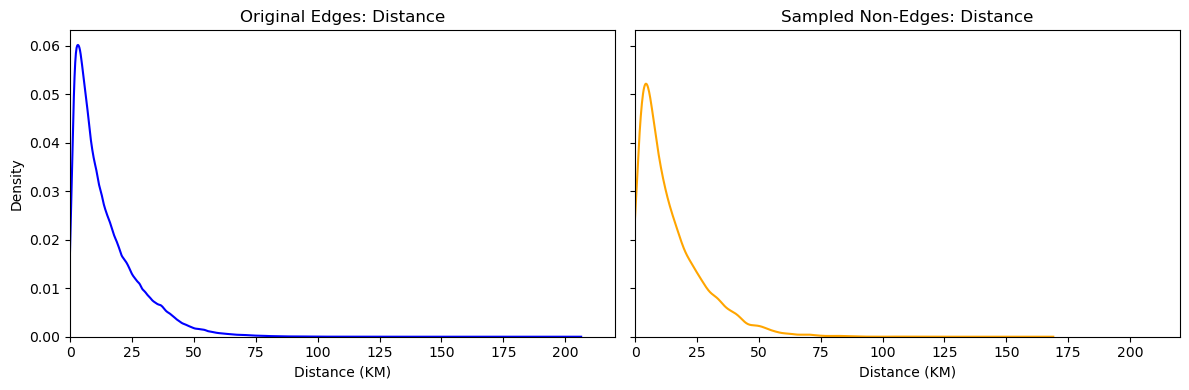

Wasserstein Distance: 0.0914


In [ ]:
# Plots/Verification

from pipeline import distribution_finder, sample_non_edges_dist_controlled, sample_non_edges_agg_stratified, load
print(f"Version: {vers} (agg={agg})")

# Generate the sample 
if agg == False:
    G = load('data/undir_trials/thresholded_networks/0_network.txt')
    distrs, sets = distribution_finder(G, bins=50)
    dist_distr = distrs[0]
    sample = sample_non_edges_dist_controlled(G, dist_distr, len(list(G.nodes())) // 2)
    original_distances = list(nx.get_edge_attributes(G, 'DIST_KM').values())
else:
    with open(fpath, 'rb') as f:
        G = pickle.load(f)
    distrs, sets = distribution_finder(G, bins=50)
    dist_distr = distrs[0]
    sample = sample_non_edges_dist_controlled(G, dist_distr, len(list(G.nodes())) // 2)
    #sample = sample_non_edges_agg_stratified(G, len(list(G.nodes())) // 2)
    original_distances = [d for d in nx.get_edge_attributes(G, 'DIST_KM').values() 
                      if d is not None and not math.isnan(d)]

locs = []
for u, v in sample:
    lat_u, lon_u = G.nodes[u]['latitude'], G.nodes[u]['longitude']
    lat_v, lon_v = G.nodes[v]['latitude'], G.nodes[v]['longitude']
    locs.append((lat_u, lon_u, lat_v, lon_v))

sampled_distances = [haversine((lat1, lon1), (lat2, lon2)) for (lat1, lon1, lat2, lon2) in locs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
pd.Series(original_distances).plot.kde(bw_method='scott', ax=axes[0], title='Original Edges: Distance', color='blue')
pd.Series(sampled_distances).plot.kde(bw_method='scott', ax=axes[1], title='Sampled Non-Edges: Distance', color='orange')
axes[0].set_xlabel('Distance (KM)')
axes[1].set_xlabel('Distance (KM)')
axes[0].set_xlim(left=0)
axes[1].set_ylim(bottom=0)
plt.tight_layout()
#plt.savefig(r'data\undir_trials\imgs\distance_distr_comp.png')
plt.show()

# wasserstein distance
print(f'Wasserstein Distance: {wasserstein_distance(original_distances, sampled_distances):.4f}')

In [ ]:
# Re-running pipeline

# --- prep ---
fpath = Path(r'data/undir_trials/thresholded_networks/0_network.txt')
G, train_neg, test_pos, test_neg = pipeline.prepare_data(fpath)

# --- metadata only ---
auc_geo, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['geo'])
auc_cat, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['cat'])
auc_vis, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['visits'])
auc_geo_cat, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['geo', 'cat'])
auc_all_metadata, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['geo', 'cat', 'visits'])

# --- embeddings only ---
auc_emb, emb_map = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['emb'])

# --- embeddings + metadata ---
auc_emb_geo, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['emb', 'geo'], embedding_map=emb_map)
auc_emb_geo_cat, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['emb', 'geo', 'cat'], embedding_map=emb_map)
auc_all, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['emb', 'geo', 'cat', 'visits'], embedding_map=emb_map)

# --- results table ---
results = [
    (['geo'],                          auc_geo),
    (['cat'],                          auc_cat),
    (['visits'],                       auc_vis),
    (['geo', 'cat'],                   auc_geo_cat),
    (['geo', 'cat', 'visits'],         auc_all_metadata),
    (['emb'],                          auc_emb),
    (['emb', 'geo'],                   auc_emb_geo),
    (['emb', 'geo', 'cat'],            auc_emb_geo_cat),
    (['emb', 'geo', 'cat', 'visits'],  auc_all),
]

df_results = pd.DataFrame(results, columns=['Features', 'AUC'])
df_results['Features'] = df_results['Features'].apply(lambda x: ' + '.join(x))
df_results['AUC'] = df_results['AUC'].round(4)

# flag embedding inclusion
df_results['Includes_Emb'] = df_results['Features'].str.contains('emb').map({True: 'with_emb', False: 'without_emb'})

In [ ]:
# AUC bar plot color-coded by embedding inclusion
plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='AUC', y='Features', hue='Includes_Emb', dodge=False, palette={'with_emb':'tab:blue','without_emb':'tab:green'})
plt.title('AUC Scores by Feature Set (Distance-Controlled Negative Sampling)')
plt.xlabel('AUC')
plt.ylabel('Feature Set')
plt.xlim(left=0.5, right=1)
for i, value in enumerate(df_results['AUC']):
    plt.text(value + 0.001, i, f"{value:.4f}", va='center')
plt.legend(title='Includes Embedding')
plt.tight_layout()
plt.savefig('data/undir_trials/imgs/auc_by_feature_barplot.png')
plt.show()

### Sequential Hyperparameter Sweep

In [ ]:
# Sequential Hyperparameter Sweep: p â†’ q â†’ dim

# Saves the split to disk at the start so it survives kernel restarts.

sweep_dir = Path('data/undir_trials/hparam_sweep')
sweep_dir.mkdir(parents=True, exist_ok=True)

# Persist the split so it can be reloaded without re-running prepare_data
with open(sweep_dir / 'sweep_split.pkl', 'wb') as f:
    pickle.dump((G, train_neg, test_pos, test_neg), f, pickle.HIGHEST_PROTOCOL)
print(f"Split saved â†’ {sweep_dir / 'sweep_split.pkl'}")

FPATH   = 'train.txt'
WORKERS = 8
MODE    = 'PreComp'   # matches the baseline cell

# Walk params that match the baseline defaults in run_pipeline
WALK_KWARGS = dict(num_walks=10, walk_length=80, window_size=10)

P_VALUES   = [0.25, 0.50, 1, 2, 4]
Q_VALUES   = [0.25, 0.50, 1, 2, 4]
DIM_VALUES = [64, 96, 160, 192]

def run_phase(param_name, param_values, fixed):
    fixed_str = ', '.join(f"{k}={v}" for k, v in fixed.items())
    print(f"\n{'='*60}")
    print(f"PHASE: sweeping {param_name}  |  fixed: {fixed_str}")
    print(f"  values: {param_values}")
    print(f"{'='*60}")

    rows = []
    for val in param_values:
        kw = {**fixed, param_name: val}
        print(f"\n  [{param_name}={val}] starting ...", flush=True)
        t0 = time.perf_counter()

        auc, _ = pipeline.run_pipeline(
            FPATH, train_neg, test_pos, test_neg,
            G=G, features=['emb'], mode=MODE, workers=WORKERS,
            **WALK_KWARGS, **kw
        )

        elapsed = time.perf_counter() - t0
        print(f"  [{param_name}={val}]  AUC = {auc:.4f}   ({elapsed/60:.1f} min)", flush=True)
        rows.append({**kw, 'auc': auc, 'time_min': elapsed / 60})

    df = pd.DataFrame(rows)
    best_val = df.loc[df['auc'].idxmax(), param_name]
    print(f"\n  --> Best {param_name} = {best_val}  (AUC = {df['auc'].max():.4f})")
    print(df[[param_name, 'auc', 'time_min']].to_string(index=False))
    return df, best_val

# â”€â”€ Phase 1: p sweep â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
p_df, best_p = run_phase('p', P_VALUES, fixed={'q': 1, 'dim': 128})
with open(sweep_dir / 'phase1_p_sweep.pkl', 'wb') as f:
    pickle.dump(p_df, f, pickle.HIGHEST_PROTOCOL)
print(f"\nSaved â†’ {sweep_dir / 'phase1_p_sweep.pkl'}")

# â”€â”€ Phase 2: q sweep â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
q_df, best_q = run_phase('q', Q_VALUES, fixed={'p': best_p, 'dim': 128})
with open(sweep_dir / 'phase2_q_sweep.pkl', 'wb') as f:
    pickle.dump(q_df, f, pickle.HIGHEST_PROTOCOL)
print(f"\nSaved â†’ {sweep_dir / 'phase2_q_sweep.pkl'}")

# â”€â”€ Phase 3: dim sweep â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
dim_df, best_dim = run_phase('dim', DIM_VALUES, fixed={'p': best_p, 'q': best_q})
with open(sweep_dir / 'phase3_dim_sweep.pkl', 'wb') as f:
    pickle.dump(dim_df, f, pickle.HIGHEST_PROTOCOL)
print(f"\nSaved â†’ {sweep_dir / 'phase3_dim_sweep.pkl'}")

# â”€â”€ Consolidate â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
all_results = {
    'phase1_p':   p_df,
    'phase2_q':   q_df,
    'phase3_dim': dim_df,
    'best': {'p': best_p, 'q': best_q, 'dim': int(best_dim)},
}
with open(sweep_dir / 'all_sweep_results.pkl', 'wb') as f:
    pickle.dump(all_results, f, pickle.HIGHEST_PROTOCOL)

print(f"\n{'='*60}")
print("SWEEP COMPLETE")
print(f"  best p   = {best_p}")
print(f"  best q   = {best_q}")
print(f"  best dim = {int(best_dim)}")
print(f"  baseline (p=1, q=1, dim=128): AUC = {p_df.loc[p_df['p']==1, 'auc'].values[0]:.4f}")
print(f"  all results â†’ {sweep_dir / 'all_sweep_results.pkl'}")
print(f"{'='*60}")

In [ ]:
sweep_dir = Path('data/undir_trials/hparam_sweep')
with open(sweep_dir / 'all_sweep_results.pkl', 'rb') as f:
    sweep_results = pickle.load(f)

p_df   = sweep_results['phase1_p']
q_df   = sweep_results['phase2_q']
dim_df = sweep_results['phase3_dim']
best   = sweep_results['best']

try:
    baseline = auc_emb
except NameError:
    baseline = 0.5896

phases = [
    (p_df,   'p',   f"p  (q=1, dim=128)",                        'tab:blue'),
    (q_df,   'q',   f"q  (p={best['p']}, dim=128)",              'tab:orange'),
    (dim_df, 'dim', f"dim  (p={best['p']}, q={best['q']})",      'tab:green'),
]

fig, axes = plt.subplots(3, 1, figsize=(8, 8))
fig.suptitle('Sequential Hyperparameter Sweep', fontsize=13, fontweight='bold')

for ax, (df, param, title, color) in zip(axes, phases):
    labels = [str(v) for v in df[param]]
    aucs   = df['auc'].values
    best_i = aucs.argmax()

    colors = [color] * len(aucs)
    colors[best_i] = 'gold'

    ax.barh(labels, aucs - 0.5, left=0.5, color=colors, edgecolor='white', height=0.55)

    ax.axvline(baseline, color='crimson', linestyle='--', linewidth=1.3,
               label=f'baseline  {baseline:.4f}')

    for i, val in enumerate(aucs):
        ax.text(val + 0.002, i, f'{val:.4f}',
                va='center', fontsize=8.5,
                fontweight='bold' if i == best_i else 'normal')

    ax.set_xlim(0.5, 1.0)
    ax.set_xlabel('AUC')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('data/undir_trials/imgs/hparam_sweep_results.png', bbox_inches='tight', dpi=150)
plt.show()

### Weighted (node2vec+)

In [ ]:
seed = 21
fpath = Path('data/undir_trials/thresholded_networks/0_network.txt')
BEST_PARAMS = dict(p=4, q=0.25, dim=192)

# function for efficiency
def run_weighted_test(weight, compress=False):
    print(f"Starting test: weight={weight}, compress={compress}")
    split_dir = Path(f'data/undir_trials/weight_trials/{weight}')
    split_dir.mkdir(parents=True, exist_ok=True)
    weightmode = 'log' if compress else 'reg'

    # read back in if already exists
    load_dir = split_dir / f'{weightmode}_split.pkl'
    if load_dir.is_file():
        print("Reading back from disk...")
        with open(load_dir, 'rb') as f:
            G, train_neg, test_pos, test_neg = pickle.load(f)
    else:
        G, train_neg, test_pos, test_neg = pipeline.prepare_data(fpath, seed=seed, compress=compress, weight=weight)
        with open(load_dir, 'wb') as f:
            pickle.dump((G, train_neg, test_pos, test_neg), f, pickle.HIGHEST_PROTOCOL)
        print(f"Saved split â†’ {split_dir / f'{weightmode}_split.pkl'}")

    auc, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, seed=seed,
                                **BEST_PARAMS, workers=6, weighted=True)

    with open(split_dir / f'{weightmode}_score.txt', 'w') as f:
        f.write(str(auc))

    # move + rename training graph to save it
    shutil.move('train.txt', split_dir / f'{weightmode}_train.txt')

    print('Saved score + training graph.\n')

# dep
run_weighted_test('dep')
run_weighted_test('dep', True)

# cov
run_weighted_test('cov')
run_weighted_test('cov', True)

# Agg Network

In [2]:
# --- initial setup ---

# bring in network
with open(fpath, 'rb') as f:
    G = pickle.load(f)

# list possible combos and permutations (sets prevent double-counting)
cats = set()
tracts = set()
for n in G.nodes():
    c, t = n.split('||')
    cats.add(c)
    tracts.add(t)
combos = list(itertools.combinations(sorted(cats), 2))
perms = list(itertools.permutations(cats, 2))

cat_to_idx = {cat: i for i, cat in enumerate(cats)}

### Basic Analyses

Edges with DEP: 5221869
count    5.221869e+06
mean     7.231684e-08
std      1.814428e-07
min      2.628360e-11
25%      2.391657e-08
50%      4.646621e-08
75%      6.602696e-08
max      3.938498e-05
dtype: float64
Zero-DEP edges: 0 (0.00%)


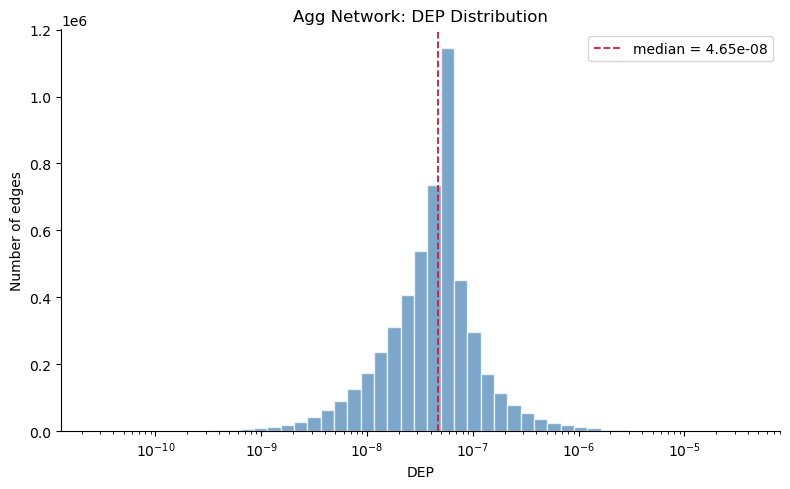


Share of total DEP accounted for by the top fraction of edges:
  top   1% of edges  ->   18.0% of total DEP
  top   5% of edges  ->   35.9% of total DEP
  top  10% of edges  ->   46.4% of total DEP
  top  25% of edges  ->   63.8% of total DEP
  top  50% of edges  ->   83.4% of total DEP

Gini coefficient of DEP: 0.549


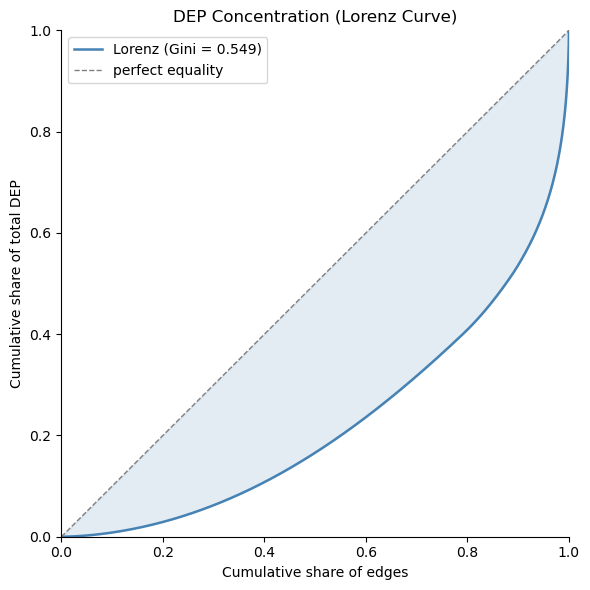

In [20]:
# --- DEP distribution (descriptive) ---

dep_vals = np.array([d for d in nx.get_edge_attributes(G, 'DEP').values() if d is not None])

print(f"Edges with DEP: {len(dep_vals)}")
print(pd.Series(dep_vals).describe())
n_zero = int((dep_vals == 0).sum())
print(f"Zero-DEP edges: {n_zero} ({n_zero / len(dep_vals):.2%})")

# histogram on log-x (DEP values are tiny and heavily right-skewed)
pos = dep_vals[dep_vals > 0]
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(pos, bins=np.logspace(np.log10(pos.min()), np.log10(pos.max()), 50),
        color='steelblue', alpha=0.7, edgecolor='white')
ax.set_xscale('log')
ax.axvline(np.median(pos), color='crimson', linestyle='--', linewidth=1.3,
           label=f'median = {np.median(pos):.2e}')
ax.set_xlabel('DEP')
ax.set_ylabel('Number of edges')
ax.set_title('Agg Network: DEP Distribution')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('imgs/agg/dep_distribution.png', dpi=300)
plt.show()

# --- concentration / inequality of total DEP (weighting sanity check) ---
# how much of the total edge weight (DEP) a top fraction of edges accounts for.
# high concentration => DEP-weighted walks are dominated by a few edges.

total_dep = dep_vals.sum()
desc = np.sort(dep_vals)[::-1]                 # descending
cum_share_top = np.cumsum(desc) / total_dep    # share of total DEP held by top-k edges
n = len(dep_vals)

print("\nShare of total DEP accounted for by the top fraction of edges:")
for q in [0.01, 0.05, 0.10, 0.25, 0.50]:
    k = max(1, int(round(q * n)))
    print(f"  top {q:>4.0%} of edges  ->  {cum_share_top[k-1]:6.1%} of total DEP")

# Gini coefficient (0 = perfectly equal, 1 = maximally concentrated)
asc = np.sort(dep_vals)
cum = np.cumsum(asc)
gini = (n + 1 - 2 * (cum.sum() / cum[-1])) / n
print(f"\nGini coefficient of DEP: {gini:.3f}")

# Lorenz curve
lorenz = np.insert(cum / cum[-1], 0, 0)
x = np.linspace(0, 1, len(lorenz))

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(x, lorenz, color='steelblue', linewidth=1.8, label=f'Lorenz (Gini = {gini:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='perfect equality')
ax.fill_between(x, lorenz, x, alpha=0.15, color='steelblue')
ax.set_xlabel('Cumulative share of edges')
ax.set_ylabel('Cumulative share of total DEP')
ax.set_title('DEP Concentration (Lorenz Curve)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('imgs/agg/dep_lorenz.png', dpi=300)
plt.show()

In [ ]:
# === check proportion of possible within-tract edges that actually exist ===

realization_rates = []
for t in tracts:
    nodes_in_tract = set(n for n in G.nodes() if t in n)
    # subgraph creates only the edges that exist between cats within the tract
    edges_in_tract = G.subgraph(nodes_in_tract).number_of_edges()
    rr = (edges_in_tract / len(combos)) * 100
    realization_rates.append([t, rr, edges_in_tract])
rr_df = pd.DataFrame(realization_rates, columns=['tract', 'rate', 'total'])

print(f'total within-tract edges: {rr_df["total"].sum()}')
print(rr_df['rate'].describe())

# --- kde plot ---

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
# stat="density" normalizes the histogram
sns.histplot(data=rr_df, x="rate", bins=20, kde=True, color="teal", alpha=0.6, stat="density")

plt.suptitle(
    "Realization Rate Distribution\n(bucket size relative to max)",
    fontsize=14,
    x=0.5,
    ha='center'
)
plt.xlabel("Realization Rate (%)", fontsize=12, x=0.45)
plt.ylabel("Density", fontsize=12)
plt.xlim(0)
plt.tight_layout()
plt.savefig('imgs/agg/rr_dist.png', dpi=500)
plt.close()
print('KDE plot saved.')

190 category pairs | 4,826,962 cross-category edges
global baseline rate r0 = 3.324e-08

edge denominator (v_i*v_j) percentiles: p10=2.68e+06, p25=8.00e+06, p50=2.61e+07, p75=8.38e+07, p90=2.41e+08

current top-8 pairs by raw mean DEP â€” median denom vs global median (2.61e+07):
  Agriculture — School                       med_den=2.06e+05 ( 0.01x global)  n=17
  Agriculture — Arts / Museum                med_den=1.05e+06 ( 0.04x global)  n=37
  Agriculture — Neighborhood Service         med_den=9.94e+05 ( 0.04x global)  n=78
  Agriculture — Public Administration        med_den=6.44e+05 ( 0.02x global)  n=70
  Arts / Museum — School                     med_den=1.17e+06 ( 0.04x global)  n=519
  Agriculture — Service                      med_den=1.14e+06 ( 0.04x global)  n=165
  Agriculture — City / Outdoors              med_den=8.89e+05 ( 0.03x global)  n=108
  Arts / Museum — Public Administration      med_den=2.47e+06 ( 0.09x global)  n=2191

alpha sweep â€” top 6 pairs by pool-then-

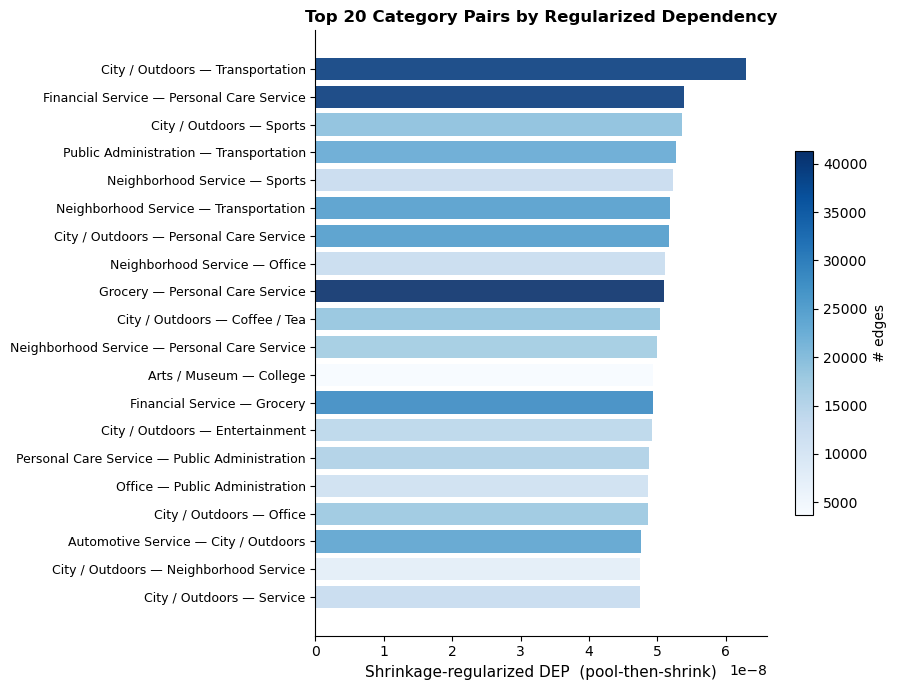

In [24]:
# -- barchart: shrinkage-regularized dependency per category pair ---
#
# Low-traffic pairs are inflated by the covisits>=1 floor: DEP >= 1/(v_i*v_j), which is
# large when the visit-product denominator is small. Neither pooling nor a threshold
# fixes it, because a uniformly low-traffic category (e.g. Agriculture) has no high-
# support edges to lean on. Empirical-Bayes shrinkage pulls each rate toward the global
# rate r0 by an amount set by its support (v_i*v_j):
#     DEP_shrunk = (covisits + alpha*r0) / (v_i*v_j + alpha)
# alpha = pseudo-exposure (same units as v_i*v_j): the traffic level at which the data
# starts to outweigh the prior. We POOL each category pair first, then shrink once with
# its TOTAL support, so a pair backed by few low-traffic edges collapses to r0 and can't
# top the ranking. (Per-edge shrinkage is the right form upstream for edge weights; a
# category-level ranking wants the pair pooled.)

# load network if needed
if 'G' not in globals():
    with open(fpath, 'rb') as f:
        G = pickle.load(f)

# --- one pass: per-edge covisits, denominator (visit-product), and category pair ---
cov_list, den_list, pair_list = [], [], []
for u, v, data in G.edges(data=True):
    c1, c2 = u.split('||')[0], v.split('||')[0]
    if c1 == c2:
        continue
    cov = data.get('N_COVISITS')
    vi = G.nodes[u].get('total_visits')
    vj = G.nodes[v].get('total_visits')
    if cov is None or vi is None or vj is None:
        continue
    cov_list.append(cov)
    den_list.append(vi * vj)
    pair_list.append(f"{c1} — {c2}" if c1 <= c2 else f"{c2} — {c1}")

edf = pd.DataFrame({'pair': pair_list,
                    'cov': np.asarray(cov_list, dtype='float64'),
                    'den': np.asarray(den_list, dtype='float64')})
edf['dep_raw'] = edf['cov'] / edf['den']

# global baseline rate r0 = pooled covisit rate across the whole network
r0 = edf['cov'].sum() / edf['den'].sum()
print(f"{edf['pair'].nunique()} category pairs | {len(edf):,} cross-category edges")
print(f"global baseline rate r0 = {r0:.3e}")

# --- diagnostic: is the inflation really driven by low support (small v_i*v_j)? ---
pct = [10, 25, 50, 75, 90]
den_pctiles = np.percentile(edf['den'], pct)
global_med_den = edf['den'].median()
print("\nedge denominator (v_i*v_j) percentiles: "
      + ", ".join(f"p{p}={v:.2e}" for p, v in zip(pct, den_pctiles)))

raw_top = (edf.groupby('pair')
           .agg(dep_raw=('dep_raw', 'mean'), med_den=('den', 'median'), n_edges=('cov', 'size'))
           .sort_values('dep_raw', ascending=False))
print(f"\ncurrent top-8 pairs by raw mean DEP â€” median denom vs global median ({global_med_den:.2e}):")
for pair, row in raw_top.head(8).iterrows():
    print(f"  {pair:<42} med_den={row['med_den']:.2e} ({row['med_den']/global_med_den:5.2f}x global)  n={int(row['n_edges'])}")

# --- pool each pair, THEN shrink once, using the pair's total support (Sum den) ---
# Shrinking per-edge then averaging leaves the pair-level estimate itself low-support
# (a mean over few edges), so small-n pairs leak back in. Pooling first means alpha
# acts on each pair's total Sum(v_i*v_j): tiny-support pairs collapse to r0.
pair_tot = edf.groupby('pair').agg(cov=('cov', 'sum'), den=('den', 'sum'), n_edges=('cov', 'size'))
pair_tot['pooled_raw'] = pair_tot['cov'] / pair_tot['den']

# alpha now lives on the scale of the per-pair TOTAL denominator
tot_pctiles = np.percentile(pair_tot['den'], pct)

def pooled_shrunk(alpha):
    return (pair_tot['cov'] + alpha * r0) / (pair_tot['den'] + alpha)

sweep_alphas = {'p25': tot_pctiles[1], 'p50': tot_pctiles[2],
                'p75': tot_pctiles[3], '3x_p50': 3 * tot_pctiles[2]}
print("\nalpha sweep â€” top 6 pairs by pool-then-shrink DEP  (n_edges in parens):")
for name, alpha in sweep_alphas.items():
    print(f"\n  alpha = {name} ({alpha:.2e}):")
    for pair, val in pooled_shrunk(alpha).sort_values(ascending=False).head(6).items():
        print(f"    {pair:<42} {val:.3e}  (n={int(pair_tot.loc[pair, 'n_edges'])})")

# --- chosen alpha for the plotted barchart (tune from the sweep above) ---
ALPHA = tot_pctiles[2]  # median per-pair total denominator
combo_stats = (pair_tot
               .assign(shrunk_dep=pooled_shrunk(ALPHA), raw_dep=pair_tot['pooled_raw'])
               .sort_values('shrunk_dep', ascending=False)
               .reset_index()[['pair', 'shrunk_dep', 'raw_dep', 'n_edges']])

print(f"\nplotting with ALPHA = {ALPHA:.3e}")
print(combo_stats.head(15).to_string(index=False))

# === top 20 bar chart, colored by edge support ===
top20 = combo_stats.head(20).copy()

fig, ax = plt.subplots(figsize=(9, 7))
norm = plt.Normalize(top20['n_edges'].min(), top20['n_edges'].max())
colors = [plt.cm.Blues(norm(v)) for v in top20['n_edges'].values[::-1]]
ax.barh(range(len(top20)), top20['shrunk_dep'].values[::-1], color=colors, alpha=0.9)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['pair'].values[::-1], fontsize=9)
ax.set_xlabel('Shrinkage-regularized DEP  (pool-then-shrink)', fontsize=11)
ax.set_title(f'Top 20 Category Pairs by Regularized Dependency',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='# edges', shrink=0.6)

plt.tight_layout()
plt.savefig('imgs/agg/perm_dep_top20.png', dpi=300, bbox_inches='tight')
plt.show()

### Plot Link Prediction Results

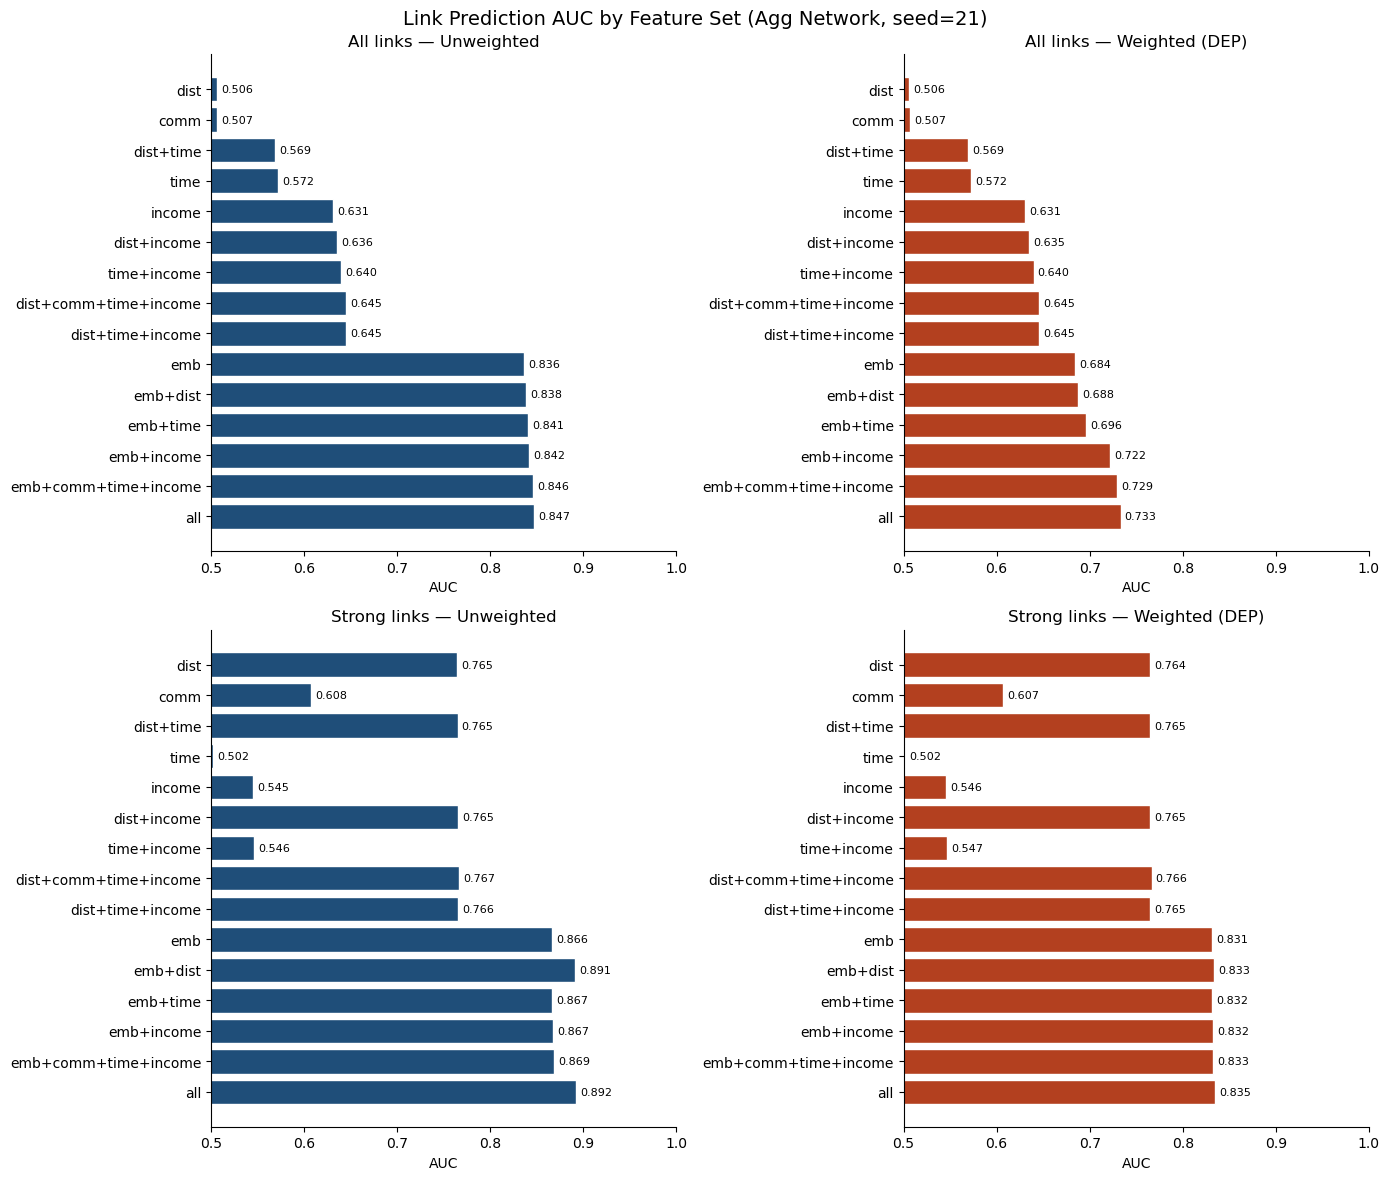

In [32]:
# --- 4-panel link prediction results: weighted/unweighted x all/strong links ---
# strength{strength} result files store two AUCs: line 1 = all-links (link
# prediction) AUC, line 2 = strong-vs-weak (strength) AUC. The comprehensive
# file packs both on each line. Weighted = weight_dep, unweighted = weight_None.

def load_strength_scores(w):
    """feat -> (all_links_auc, strong_links_auc) for a given network weight."""
    wtag = w if w else 'None'
    d = f"data/agg/undir_dep/tests/seed{seed}/weight_{w}"
    scores = {}
    # comprehensive file first (per-feature files below override it)
    for path in glob.glob(os.path.join(d, f"w{wtag}-strength{strength}_comprehensive.txt")):
        with open(path) as f:
            for line in f:
                m = re.search(r"features:\s*(\S+)\s*->\s*AUC:\s*([\d.]+)\s*\|\s*Strength AUC:\s*([\d.]+)", line)
                if m:
                    scores[m.group(1)] = (float(m.group(2)), float(m.group(3)))
    # per-feature files (includes the emb-only results)
    for path in glob.glob(os.path.join(d, f"w{wtag}-strength{strength}-feats_*.txt")):
        m = re.search(r"feats_(.+)\.txt$", os.path.basename(path))
        if not m:
            continue
        lines = [ln.strip() for ln in open(path) if ln.strip()]
        if len(lines) >= 2:
            scores[m.group(1)] = (float(lines[0]), float(lines[1]))
    return scores

# cool for unweighted, warm for weighted; same shade across both rows
columns = [
    ("Unweighted", load_strength_scores(None), "#1f4e79"),
    ("Weighted (DEP)", load_strength_scores('dep'), "#b3401f"),
]
rows = [
    ("All links", 0),     # line 1 -> link-prediction AUC
    ("Strong links", 1),  # line 2 -> strong-vs-weak AUC
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for c, (col_label, scores, color) in enumerate(columns):
    # fix feature order by all-links AUC; strong-links row reuses it
    order = sorted(scores, key=lambda f: scores[f][0])
    for r, (row_label, idx) in enumerate(rows):
        ax = axes[r, c]
        labels = [f.replace("_", "+") for f in order]
        values = [scores[f][idx] for f in order]
        bars = ax.barh(labels, values, color=color, edgecolor="white")
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
        ax.set_xlabel("AUC")
        ax.set_title(f"{row_label} — {col_label}")
        ax.set_xlim(0.5, 1.0)
        ax.spines[["top", "right"]].set_visible(False)
        ax.invert_yaxis()

fig.suptitle(f"Link Prediction AUC by Feature Set (Agg Network, seed={seed})", fontsize=14)
plt.tight_layout()
plt.savefig(f"imgs/agg/link_pred_auc_4panel_s{seed}_strength{strength}.png", dpi=150)
plt.show()


### Geographic Dependency Analysis (Tract + Category)

per-edge shrinkage: r0 = 4.702e-08 | alpha = 2.533e+07
#1: ('Personal Care Service', 'Shopping') | rho = -0.623 | n = 82631
#2: ('Food', 'Shopping') | rho = -0.618 | n = 146477
#3: ('Grocery', 'Shopping') | rho = -0.608 | n = 59812
#4: ('Financial Service', 'Shopping') | rho = -0.608 | n = 56756
#5: ('Automotive Service', 'Shopping') | rho = -0.601 | n = 81266
#6: ('Food', 'Personal Care Service') | rho = -0.596 | n = 107066
#7: ('Shopping', 'Transportation') | rho = -0.593 | n = 111541
#8: ('Automotive Service', 'Personal Care Service') | rho = -0.584 | n = 54286
#9: ('Personal Care Service', 'Transportation') | rho = -0.584 | n = 79076
#10: ('Automotive Service', 'Food') | rho = -0.581 | n = 104459
#11: ('Financial Service', 'Food') | rho = -0.579 | n = 72430
#12: ('Financial Service', 'Personal Care Service') | rho = -0.578 | n = 39023


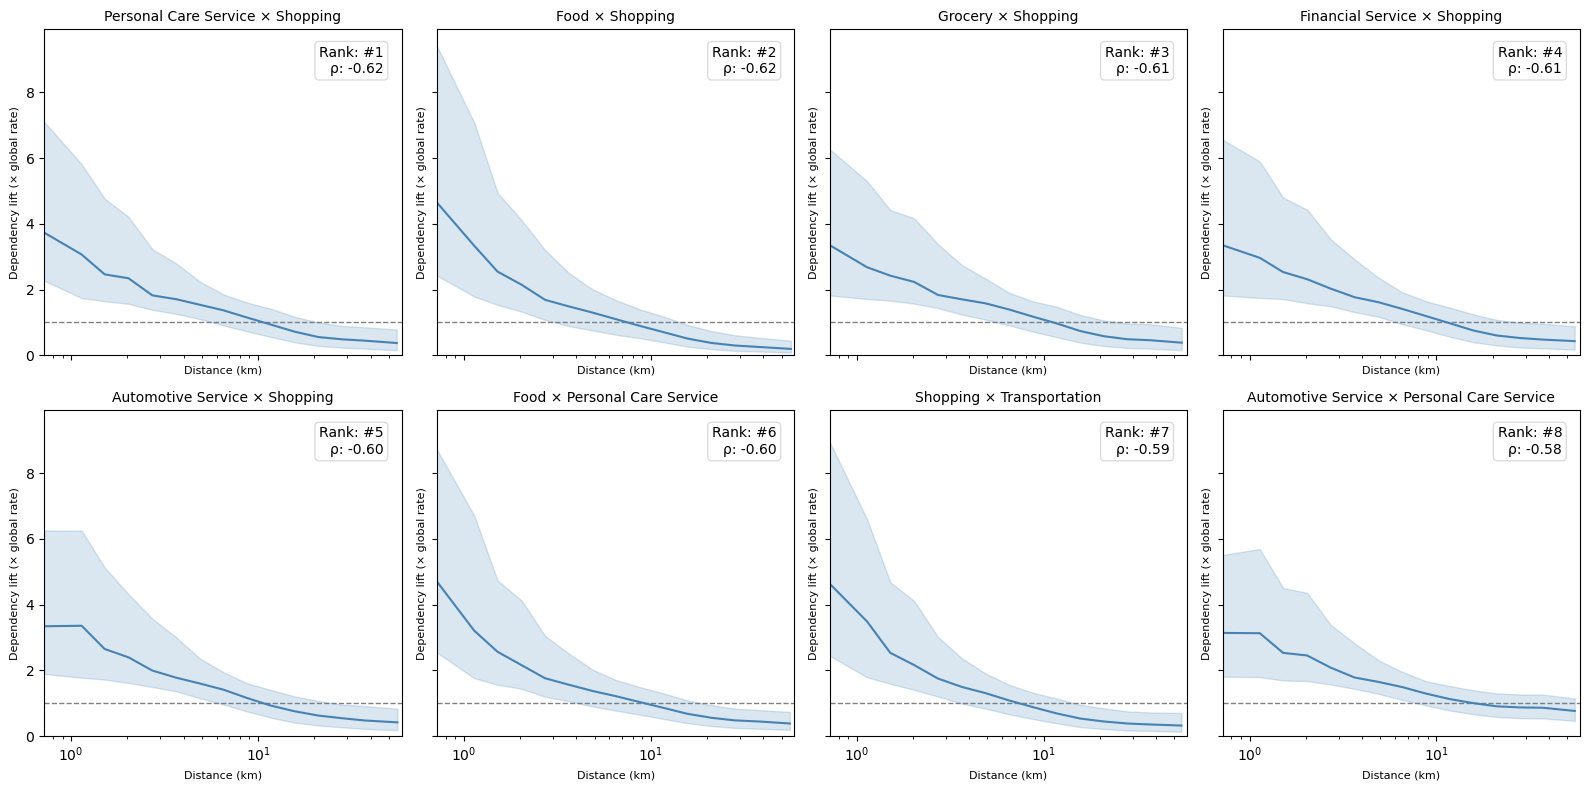

In [30]:
# dependency (shrinkage-normalized) as a function of distance, per category pair
from scipy.stats import spearmanr

# --- per-edge shrunk DEP + distance (empirical-Bayes shrinkage; cross-category only) ---
#   DEP_shrunk = (cov + alpha*r0)/(v_i*v_j + alpha),  plotted as lift = DEP_shrunk / r0
#   (lift = 1 -> global-average dependency; >1 -> more dependent than typical)
e_combo, e_dist, e_cov, e_den = [], [], [], []
for u, v, data in G.edges(data=True):
    c1, c2 = u.split('||')[0], v.split('||')[0]
    if c1 == c2:                       # skip within-category (same POI type)
        continue
    dist = data.get('DIST_KM')
    cov = data.get('N_COVISITS')
    vi = G.nodes[u].get('total_visits')
    vj = G.nodes[v].get('total_visits')
    if dist is None or cov is None or vi is None or vj is None:
        continue
    e_combo.append(tuple(sorted((c1, c2))))
    e_dist.append(dist)
    e_cov.append(cov)
    e_den.append(vi * vj)

e_dist = np.asarray(e_dist, dtype='float64')
e_cov = np.asarray(e_cov, dtype='float64')
e_den = np.asarray(e_den, dtype='float64')
r0 = e_cov.sum() / e_den.sum()
alpha = np.median(e_den)
e_lift = ((e_cov + alpha * r0) / (e_den + alpha)) / r0   # lift over the global rate
print(f"per-edge shrinkage: r0 = {r0:.3e} | alpha = {alpha:.3e}")

# group (dist, lift) per unordered cross-category combo
combo_to_data = defaultdict(list)
for c, d, lf in zip(e_combo, e_dist, e_lift):
    combo_to_data[c].append((d, lf))

# --- rank by distance-sensitivity: |Spearman(dist, dep)| (rank-based, log/linear agree) ---
MIN_EDGES_RANK = 300   # need enough support for a stable correlation
rho = {}
for combo, vals in combo_to_data.items():
    if len(vals) < MIN_EDGES_RANK:
        continue
    dd = np.array([d for d, _ in vals])
    ll = np.array([x for _, x in vals])
    m = dd > 0
    if m.sum() < MIN_EDGES_RANK:
        continue
    r, _ = spearmanr(dd[m], ll[m])
    if np.isfinite(r):
        rho[combo] = r
top_combos = sorted(rho, key=lambda c: abs(rho[c]), reverse=True)[:12]
for i, c in enumerate(top_combos, 1):
    print(f'#{i}: {c} | rho = {rho[c]:+.3f} | n = {len(combo_to_data[c])}')

# --- shared axes: common distance bins/xlim + a common ylim across panels (lift units) ---
N_BINS = 15
MIN_PER_BIN = 15
pos = e_dist > 0
DIST_XLIM = tuple(np.percentile(e_dist[pos], [1, 99]))
bin_edges = np.geomspace(DIST_XLIM[0], DIST_XLIM[1], N_BINS + 1)

def binned(dists, lifts):
    dists, lifts = np.asarray(dists), np.asarray(lifts)
    m = dists > 0
    dists, lifts = dists[m], lifts[m]
    idx = np.digitize(dists, bin_edges[1:-1])
    centers, medians, lowers, uppers = [], [], [], []
    for b in range(N_BINS):
        mask = idx == b
        if mask.sum() < MIN_PER_BIN:
            continue
        centers.append(dists[mask].mean())
        medians.append(np.median(lifts[mask]))
        q25, q75 = np.percentile(lifts[mask], [25, 75])
        lowers.append(q25)
        uppers.append(q75)
    return (np.array(centers), np.array(medians), np.array(lowers), np.array(uppers))

# pre-pass: compute all panels + a shared y-range that brackets what's drawn
panel_stats, ylo, yhi = {}, np.inf, -np.inf
for combo in top_combos[:8]:
    st = binned([d for d, _ in combo_to_data[combo]], [x for _, x in combo_to_data[combo]])
    panel_stats[combo] = st
    if len(st[2]):
        ylo = min(ylo, st[2].min())
        yhi = max(yhi, st[3].max())
pad = 0.05 * (yhi - ylo) if np.isfinite(yhi - ylo) and yhi > ylo else 0
DIST_YLIM = (max(0.0, ylo - pad), yhi + pad)

# --- plot ---
n_cols = 4
n_rows = math.ceil(len(top_combos[:8]) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4), sharex=True, sharey=True)
axes = axes.flatten()

for i, combo in enumerate(top_combos[:8]):
    ax = axes[i]
    centers, medians, lowers, uppers = panel_stats[combo]
    if not len(centers):
        continue
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, zorder=0)  # global average
    ax.plot(centers, medians, color='steelblue', linewidth=1.5)
    ax.fill_between(centers, lowers, uppers, alpha=0.2, color='steelblue')
    ax.set_xscale('log')
    ax.set_xlim(DIST_XLIM)
    ax.set_ylim(DIST_YLIM)
    ax.text(0.95, 0.95, f"Rank: #{i+1}\nρ: {rho[combo]:+.2f}",
            transform=ax.transAxes, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='lightgray'))
    ax.set_title(f"{combo[0]} × {combo[1]}", fontsize=10)
    ax.set_xlabel('Distance (km)', fontsize=8)
    ax.set_ylabel('Dependency lift (× global rate)', fontsize=8)

for j in range(len(top_combos[:8]), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('imgs/agg/geo_cat_dep/dep_dist_distr.png', dpi=300)
plt.show()

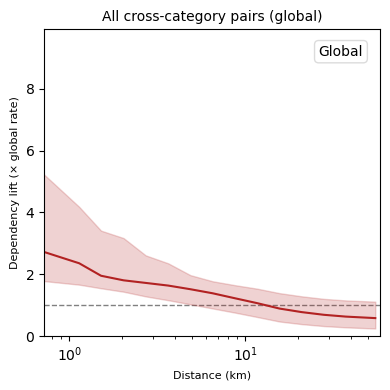

In [31]:
# --- global dep-vs-distance (shrinkage-normalized, all cross-category pairs pooled) ---
# per-edge shrunk DEP as lift over r0; axes forced to the per-combo limits for comparability.
dists, covs, dens = [], [], []
for u, v, data in G.edges(data=True):
    c1, c2 = u.split('||')[0], v.split('||')[0]
    if c1 == c2:
        continue
    dist = data.get('DIST_KM')
    cov = data.get('N_COVISITS')
    vi = G.nodes[u].get('total_visits')
    vj = G.nodes[v].get('total_visits')
    if dist is None or cov is None or vi is None or vj is None:
        continue
    dists.append(dist)
    covs.append(cov)
    dens.append(vi * vj)
dists = np.asarray(dists, dtype='float64')
covs = np.asarray(covs, dtype='float64')
dens = np.asarray(dens, dtype='float64')
r0 = covs.sum() / dens.sum()
alpha = np.median(dens)
lifts = ((covs + alpha * r0) / (dens + alpha)) / r0

N_BINS = 15
MIN_PER_BIN = 15
pos = dists > 0
dists, lifts = dists[pos], lifts[pos]

# reuse shared limits from the per-combo cell for comparability (fallback if run alone)
XLIM = DIST_XLIM if 'DIST_XLIM' in globals() else tuple(np.percentile(dists, [1, 99]))
bin_edges = np.geomspace(XLIM[0], XLIM[1], N_BINS + 1)
bin_idx = np.digitize(dists, bin_edges[1:-1])
centers, medians, lowers, uppers = [], [], [], []
for b in range(N_BINS):
    mask = bin_idx == b
    if mask.sum() < MIN_PER_BIN:
        continue
    centers.append(dists[mask].mean())
    medians.append(np.median(lifts[mask]))
    q25, q75 = np.percentile(lifts[mask], [25, 75])
    lowers.append(q25)
    uppers.append(q75)
centers = np.array(centers)
medians = np.array(medians)
lowers = np.array(lowers)
uppers = np.array(uppers)

fig, ax = plt.subplots(figsize=(4, 4))
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, zorder=0)  # global average
ax.plot(centers, medians, color='firebrick', linewidth=1.5)
ax.fill_between(centers, lowers, uppers, alpha=0.2, color='firebrick')
ax.set_xscale('log')
ax.set_xlim(XLIM)
if 'DIST_YLIM' in globals():
    ax.set_ylim(DIST_YLIM)

ax.text(0.95, 0.95, "Global",
        transform=ax.transAxes, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='lightgray'))
ax.set_title("All cross-category pairs (global)", fontsize=10)
ax.set_xlabel('Distance (km)', fontsize=8)
ax.set_ylabel('Dependency lift (× global rate)', fontsize=8)
plt.tight_layout()
plt.savefig('imgs/agg/geo_cat_dep/global_dist_distr.png', dpi=300)
plt.show()

In [15]:
# --- tract-level permutation dependency storage ---

# main loop
rows = []
for perm in tqdm(perms):
    s, t = perm
    for tract in tracts:
        nodes_in_tract = [n for n in G.nodes() if n.split('||')[1] == tract]
        target_node = next((n for n in nodes_in_tract if n.split('||')[0] == t), None)
        if target_node:
            # retrieve all incident edges whose neighbor is the chosen source cat
            edges_to_take = [
                (u, v) for (u, v) in G.edges(target_node) if v.split('||')[0] == s
            ]
            # store
            median_dep = np.median([G.edges[u, v].get('DEP', 0.0) for (u, v) in edges_to_take])
            sum_dep = np.sum([G.edges[u, v].get('DEP', 0.0) for (u, v) in edges_to_take])
            rows.append(
                {'tract': tract, 'source_cat': s, 'target_cat': t, 'median_dep': median_dep, 'sum_dep': sum_dep}
            )
        else:
            continue

# convert to df and save
dep_df = pd.DataFrame(rows)
dep_df.to_parquet('data/agg/undir_dep/cat_dep_undir.parquet', index=False)

print(f"Saved {len(dep_df)} rows â€” {dep_df['tract'].nunique()} tracts, {dep_df[['target_cat','source_cat']].drop_duplicates().shape[0]} perms")

  0%|          | 0/380 [00:00<?, ?it/s]

c:\Users\User\anaconda3\envs\depnet\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\User\anaconda3\envs\depnet\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Saved 276184 rows â€” 1027 tracts, 380 perms


In [17]:
# --- mapping setup and plotting function ---

# import data
stats = pd.read_parquet('data/agg/undir_dep/cat_dep_undir.parquet')
cbg_gdf = gpd.read_file('data/geo/tl_2025_25_bg.shp').to_crs('EPSG:4326')

# agg shapefile up to tract level
cbg_gdf['tract'] = cbg_gdf['GEOID'].str.slice(0, 11)
tract_gdf = cbg_gdf.dissolve(by='tract', aggfunc='first')
tract_gdf = tract_gdf.reset_index()

def map_dep(to_plot, map_vers='perm', perm_type=None, save_name='unnamed', rank=None):
    
    if map_vers == 'single':
        mapping_df = stats[stats['source_cat'].eq(to_plot) | stats['target_cat'].eq(to_plot)]
        mapping_df = mapping_df.groupby('tract')['median_dep'].median().reset_index()
        title_text = f"Median Visit Dependency of Permutations Involving {to_plot} by Census Tract"
    
    elif map_vers == 'perm':
        first, second = to_plot
        if perm_type == 'grouped':
            mapping_df = stats[stats['source_cat'].isin(first) & (stats['target_cat'].isin(second))]
            mapping_df = mapping_df.groupby('tract')['median_dep'].median().reset_index()
            title_text = f"Median Visit Dependency: {first} â†’ {second} by Census Tract"
        else:
            filtered_df = stats[(stats['source_cat'] == first) & (stats['target_cat'] == second)]
            mapping_df = filtered_df[['tract', 'median_dep']]
            title_text = f"Visit Dependency: {first} â†’ {second} by Census Tract"

    merged_gdf = tract_gdf.merge(mapping_df, on='tract')

    fig, ax = plt.subplots(figsize=(10, 8))

    merged_gdf.plot(
        column='median_dep', 
        cmap='Reds', 
        linewidth=0.4, 
        ax=ax, 
        edgecolor=".4",
        legend=True
    )

    if rank is not None:
        ax.text(
            0.98, 0.97, f"Rank #{rank}",
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8)
        )
    
    plt.xticks(rotation=90)
    ax.set_title(title_text, fontsize=14, fontweight='bold', pad=15)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(
        f'imgs/agg/geo_cat_dep/maps/gcv_{save_name}.png', 
        dpi=500,
        bbox_inches='tight',
    )
    plt.close(fig)

    print(f'{to_plot} plotted and saved successfully.')

In [22]:
# --- map the same ones found from KS test ---

# load stuff back in if needed

if 'stats' not in globals() and 'stats' not in locals() or stats is None or \
   'G' not in globals() and 'G' not in locals() or G is None:
    
    print('df or network not loaded or is None. Loading in.')
    stats = pd.read_parquet('data/agg/undir_dep/cat_dep_undir.parquet')
    
    with open(fpath, 'rb') as f:
        G = pickle.load(f)

# feed the function

if not top_combos:
    with open('data/agg/geo_cat_dep/top_combos.pkl', 'rb') as f:
        top_combos = pickle.load(f)

topN = top_combos[:8]

for i, combo in enumerate(topN, 1):
    elem1, elem2 = combo[0].split(' ')[0].lower(), combo[1].split(' ')[0].lower()
    map_dep(combo, save_name=f"{elem1}_{elem2}", rank=i)

('Arts / Museum', 'Public Administration') plotted and saved successfully.
('Arts / Museum', 'City / Outdoors') plotted and saved successfully.
('Arts / Museum', 'College') plotted and saved successfully.
('City / Outdoors', 'Public Administration') plotted and saved successfully.
('City / Outdoors', 'School') plotted and saved successfully.
('Public Administration', 'School') plotted and saved successfully.
('Arts / Museum', 'School') plotted and saved successfully.
('Neighborhood Service', 'Public Administration') plotted and saved successfully.
